In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from selfrf.utils.visualizer import visualize_batch
from selfrf.pretraining.factories import build_dataloader
from selfrf.pretraining.config import TrainingConfig
from selfrf.pretraining.utils.enums import DatasetType, SSLModelType

0it [00:00, ?it/s]

In [3]:
ROOT = Path("../datasets")

# BYOL

In [6]:
byol_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

byol_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.BYOL,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Wideband

In [5]:
datamodule = build_dataloader(byol_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

Train Dataset: Wideband, Impairment Level 2, 5000 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/train but is different than current dataset.
Differences:
	seed = 1679005854764738845 (404951623201600874 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.
Val Dataset: Wideband, Impairment Level 2, 500 samples
Dataset exists at ../datasets/torchsig_wideband_impaired/val but is different than current dataset.
Differences:
	seed = 13987271738230088056 (10153248197645300753 found)
If you want to overwrite dataset on disk, set overwrite = True for the DatasetCreator.
Not regenerating. Using dataset on disk.


In [6]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")


KeyError: '1181'

Narrowband

In [7]:
print("🧠 SSL model:", type(byol_narrowband_config.ssl_model), byol_narrowband_config.ssl_model)

datamodule = build_dataloader(byol_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {byol_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {byol_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.BYOL
[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


DatasetSignal: DatasetSignal(data=[ 1.7265274e-05+1.4336499e-06j -9.4307579e-06-4.3911305e-06j
  2.6874691e-06+3.4133634e-06j ...  7.8052712e-05+5.6648976e-05j
  2.6439586e-05+4.5774097e-05j  1.3535331e-05+3.2511740e-05j], metadata=[SignalMetadata(center_freq=-23652242.5, bandwidth=8019431, start_in_samples=1645, duration_in_samples=4096, snr_db=0.0, class_name=SIGINTDAY2021_PulseRadar05 - Subpulse 2, class_index=15)])
DatasetSignal: DatasetSignal(data=[ 0.00390625+0.j         -0.00292969-0.00097656j -0.00195312-0.00292969j
 ...  0.00146484-0.00146484j -0.00097656+0.00097656j
 -0.00048828-0.00097656j], metadata=[SignalMetadata(center_freq=35190272.0, bandwidth=15104, start_in_samples=0, duration_in_samples=4096, snr_db=0.0, class_name=SIGENCESim FM15kHz, class_index=31)])
DatasetSignal: DatasetSignal(data=[ 0.00048828+0.00146484j  0.00048828+0.00097656j -0.00097656-0.00097656j
 ...  0.00048828+0.00097656j  0.00097656+0.00244141j
  0.00244141+0.00146484j], metadata=[SignalMetadata(cente

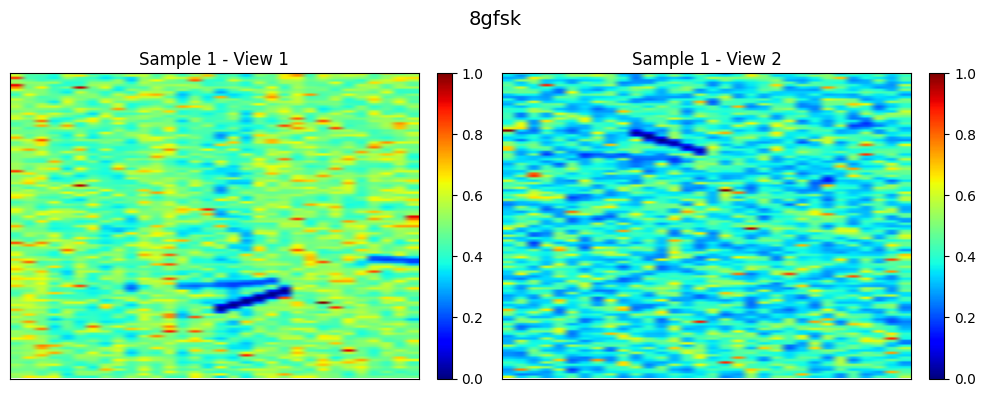

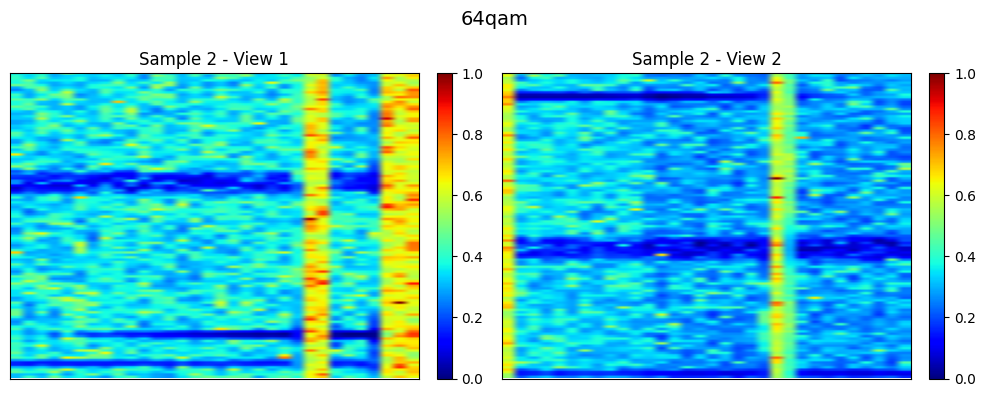

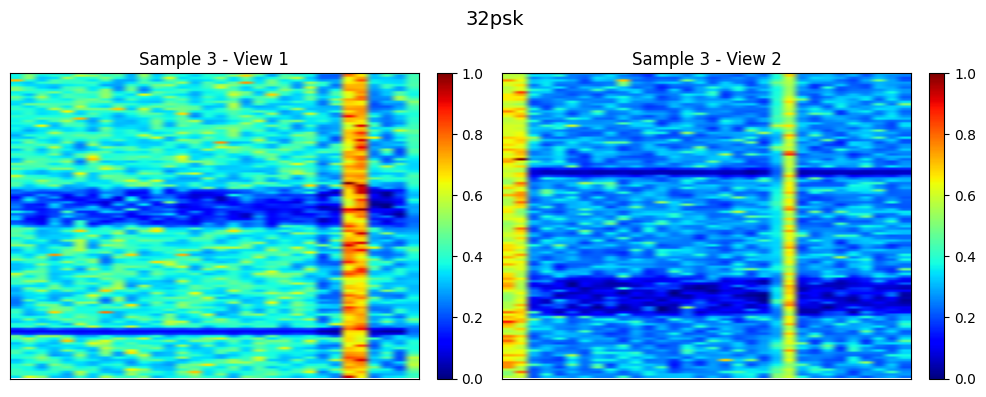

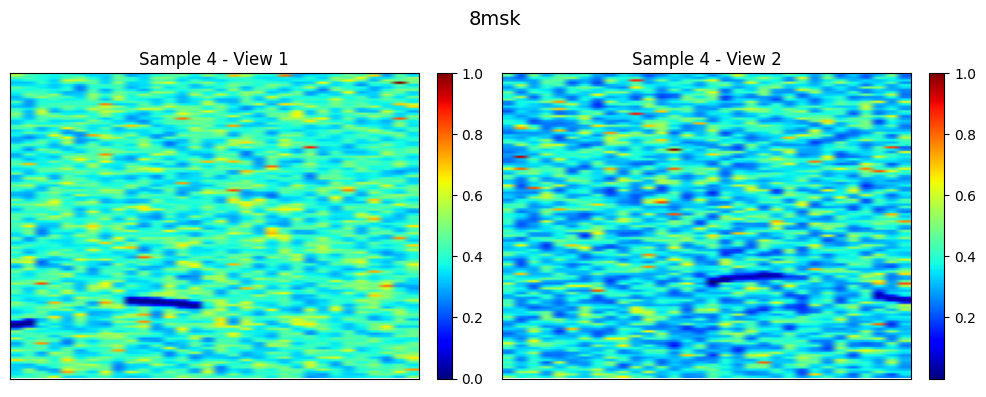

In [9]:
#datamodule.num_workers = 0
loader = datamodule.train_dataloader()
batch = next(iter(loader))
visualize_batch(batch, mode="spectrogram")

# DenseCL

In [ ]:
densecl_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    download=False,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=512,
    num_samples=10,
)

densecl_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_NARROWBAND,
    download=True,
    spectrogram=True,
    ssl_model=SSLModelType.DENSECL,
    batch_size=2,
    nfft=256,
)

In [ ]:
datamodule = build_dataloader(densecl_wideband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

In [ ]:
datamodule = build_dataloader(densecl_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")

In [ ]:
visualize(10, datamodule.train_dataloader())

## DINO

In [7]:
dino_wideband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.TORCHSIG_WIDEBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=1,
    nfft=512,
)

dino_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.DINO,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Narrowband

In [4]:
print("🧠 SSL model:", type(dino_narrowband_config.ssl_model), dino_narrowband_config.ssl_model)

datamodule = build_dataloader(dino_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {dino_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {dino_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

NameError: name 'dino_narrowband_config' is not defined

📊 Sample Metadata for Inspection:
📊 Matched Sample Metadata:
🧩 Sample 1: Class Index 8 (ShortPulseStudy_Type2_10usec)
  Bandwidth      : 3552913
  Duration       : 5e-05
  Center Freq    : 1981423345.5
----------------------------------------
🧩 Sample 2: Class Index 4 (SIGINTDAY2021_PulseRadar03)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 3: Class Index 15 (SIGINTDAY2021_PulseRadar06 - Subpulse 1)
  Bandwidth      : 3649902
  Duration       : 5e-05
  Center Freq    : 1981446337.0
----------------------------------------
🧩 Sample 4: Class Index 9 (ShortPulseStudy_Type6_10usec)
  Bandwidth      : 3548516
  Duration       : 5e-05
  Center Freq    : 1995691089.0
----------------------------------------


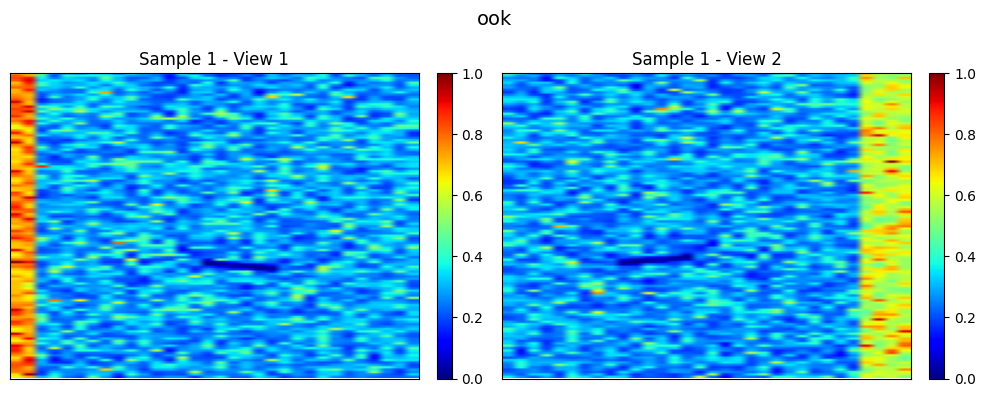

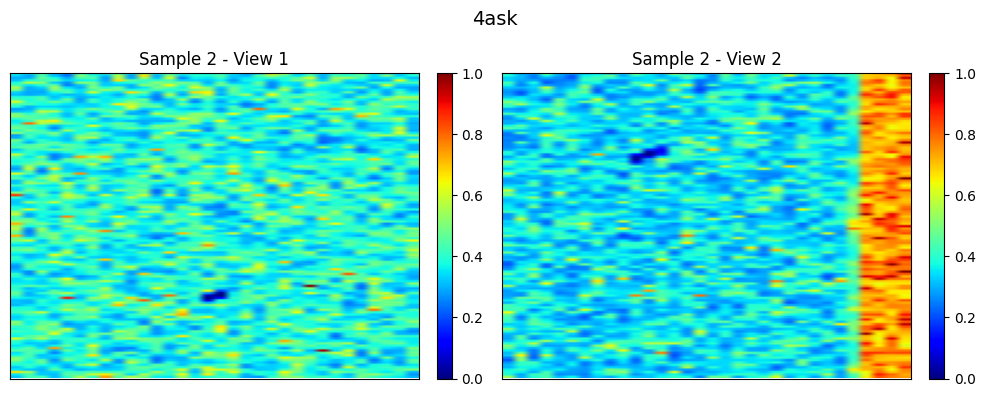

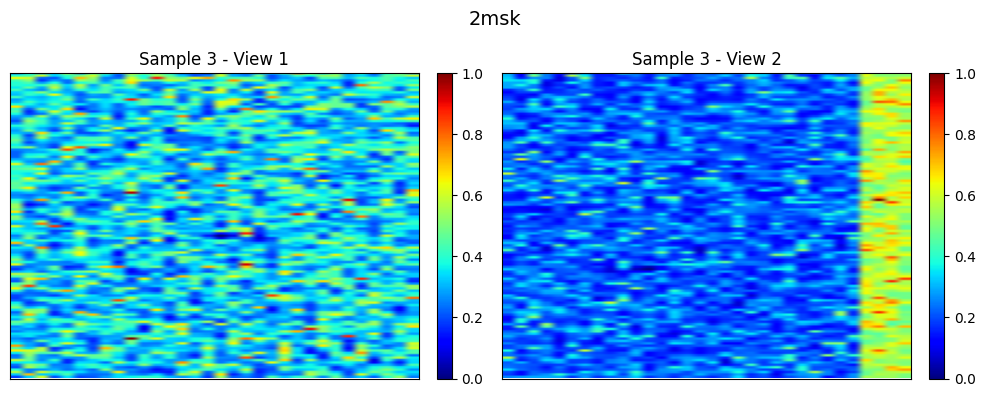

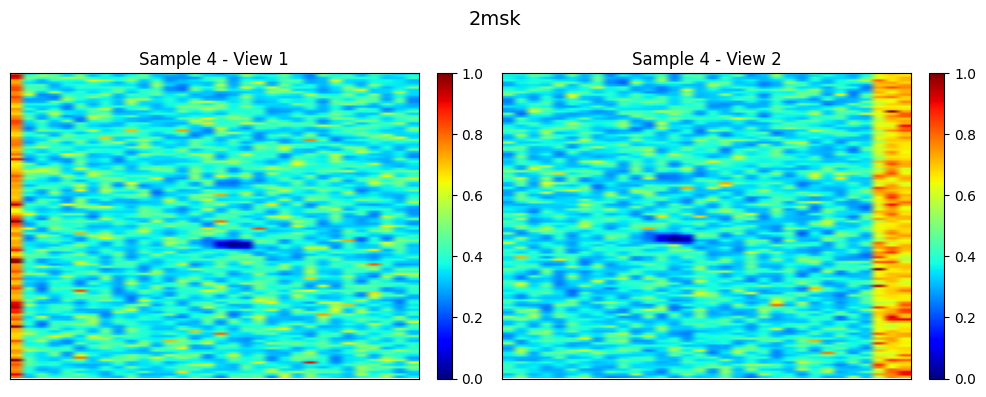

In [9]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
print("📊 Sample Metadata for Inspection:")
import json

# 🔁 Load feature vectors once
with open("/home/airbus/selfRF/datasets/NARROWBAND_ZARR/feature_vectors.json", "r") as f:
    feature_vectors = json.load(f)

raw_dataset = datamodule.train_dataset

print("📊 Matched Sample Metadata:")
for i in range(4):  # visualize samples 1–4
    signal, meta_tuple = raw_dataset[i]
    class_index = meta_tuple[0][0]
    class_name = meta_tuple[1][0]

    # ✅ Match by sample index, not class_index
    fv = feature_vectors[i]

    print(f"🧩 Sample {i+1}: Class Index {class_index} ({class_name})")
    print("  Bandwidth      :", fv.get("original_bandwidth"))
    print("  Duration       :", fv.get("duration"))
    print("  Center Freq    :", fv.get("original_center_freq"))
    print("-" * 40)


visualize_batch(batch, mode="spectrogram")

## MOCO_V3

In [4]:
mocov3_narrowband_config = TrainingConfig(
    root=ROOT ,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=True,
    ssl_model=SSLModelType.MOCOV3,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

Narrowband

In [5]:
print("🧠 SSL model:", type(mocov3_narrowband_config.ssl_model), mocov3_narrowband_config.ssl_model)

datamodule = build_dataloader(mocov3_narrowband_config)
print(f"🧪 Using DataModule: {type(datamodule)}")
print(f"🧪 Dataset type: {mocov3_narrowband_config.dataset}")
print(f"🧪 Dataset root path: {mocov3_narrowband_config.root}")

datamodule.prepare_data()

datamodule.setup("fit")

🧠 SSL model: <enum 'SSLModelType'> SSLModelType.MOCOV3
[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate
🧪 Using DataModule: <class 'selfrf.data.iqdm.iqdm_modules.IQDMNarrowbandDataModule'>
🧪 Dataset type: DatasetType.IQDM_NARROWBAND
🧪 Dataset root path: ../datasets


📊 Sample Metadata for Inspection:
📊 Matched Sample Metadata:
🧩 Sample 1: Class Index 0 (ShortPulseStudy_Type1_10usec)
  Bandwidth      : None
  Duration       : 0.009838867187500001
  Center Freq    : None
----------------------------------------
🧩 Sample 2: Class Index 4 (SIGINTDAY2021_PulseRadar03)
  Bandwidth      : None
  Duration       : 0.009851074218749999
  Center Freq    : None
----------------------------------------
🧩 Sample 3: Class Index 3 (ShortPulseStudy_Type3_10usec)
  Bandwidth      : None
  Duration       : 0.009851074218749999
  Center Freq    : None
----------------------------------------
🧩 Sample 4: Class Index 0 (ShortPulseStudy_Type1_10usec)
  Bandwidth      : None
  Duration       : 0.009851074218749999
  Center Freq    : None
----------------------------------------


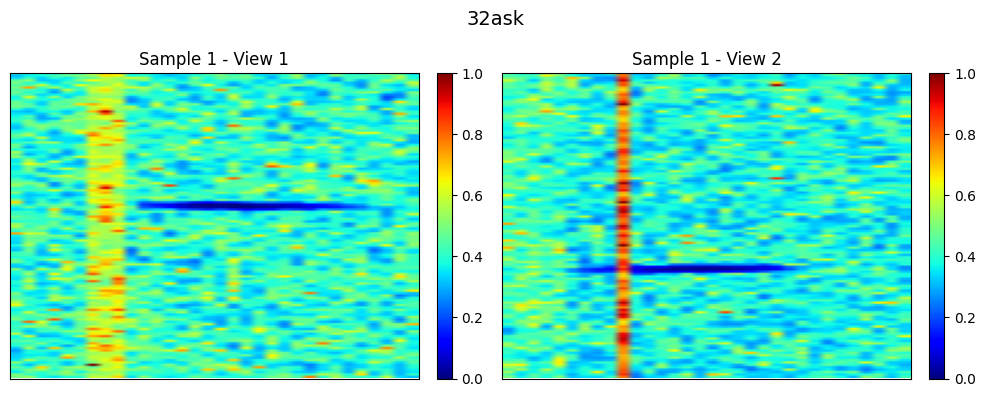

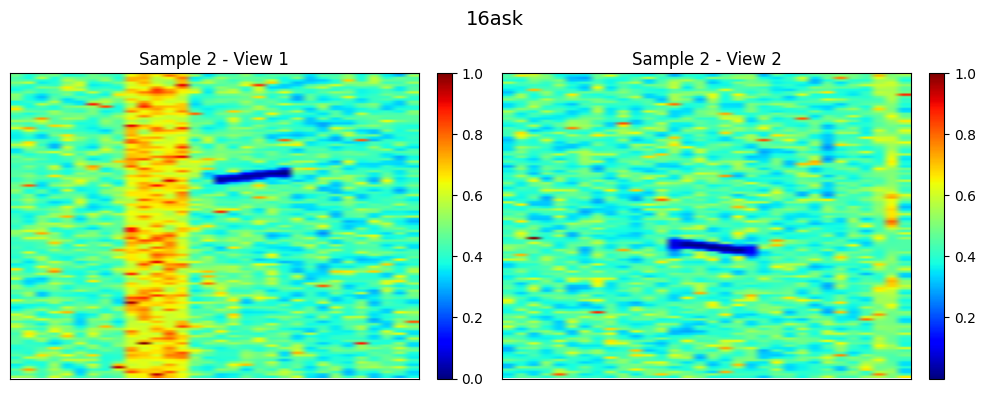

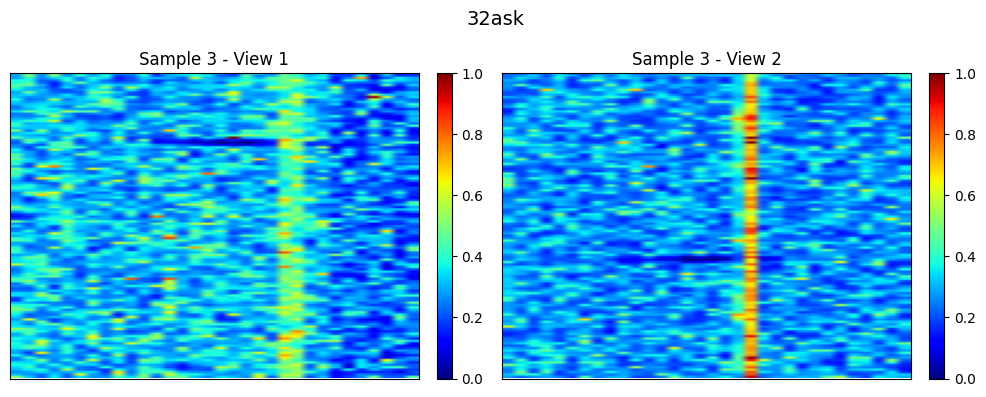

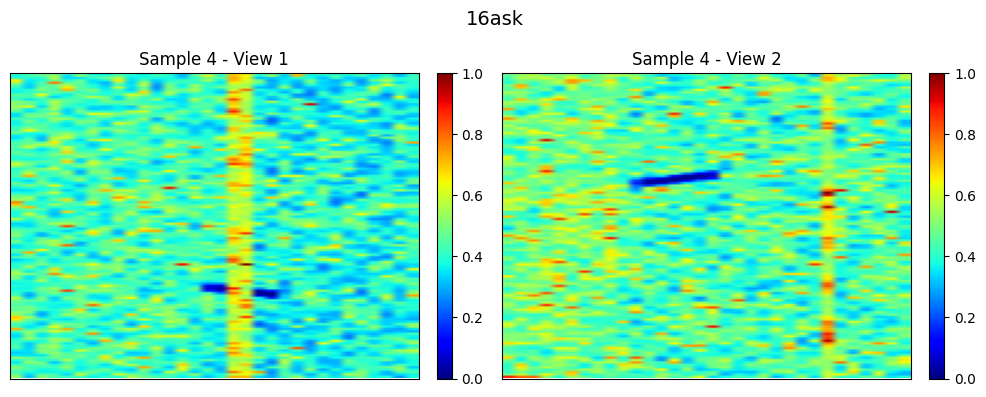

In [6]:
loader = datamodule.train_dataloader()
batch = next(iter(loader))
print("📊 Sample Metadata for Inspection:")
import json

# 🔁 Load feature vectors once
with open("/home/airbus/selfRF/datasets/NARROWBAND_ZARR/feature_vectors.json", "r") as f:
    feature_vectors = json.load(f)

raw_dataset = datamodule.train_dataset

print("📊 Matched Sample Metadata:")
for i in range(4):  # visualize samples 1–4
    signal, meta_tuple = raw_dataset[i]
    class_index = meta_tuple[0][0]
    class_name = meta_tuple[1][0]

    # ✅ Match by sample index, not class_index
    fv = feature_vectors[i]

    print(f"🧩 Sample {i+1}: Class Index {class_index} ({class_name})")
    print("  Bandwidth      :", fv.get("original_bandwidth"))
    print("  Duration       :", fv.get("duration"))
    print("  Center Freq    :", fv.get("original_center_freq"))
    print("-" * 40)


visualize_batch(batch, mode="spectrogram")

[DEBUG] Building collate function. Validation: False | Stage: ssl
[DEBUG] Using MultiViewCollate
[DEBUG] Building collate function. Validation: True | Stage: ssl
[DEBUG] Using MultiViewCollate


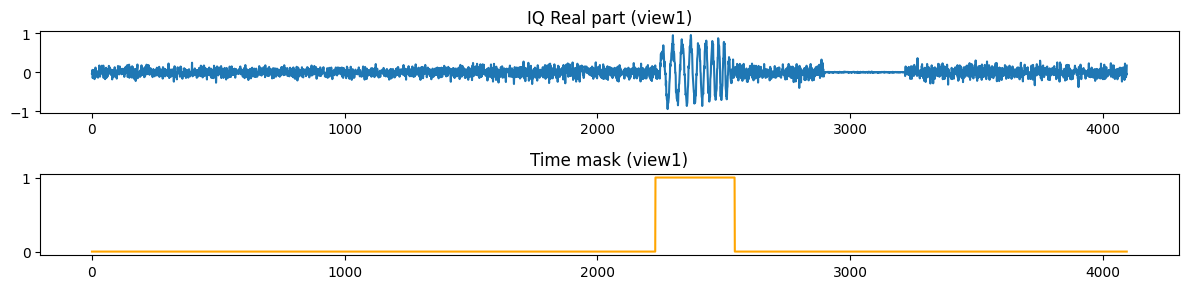

In [7]:
from selfrf.pretraining.config import TrainingConfig
# ✅ Build config as you normally do
mocov3_narrowband_config = TrainingConfig(
    root=ROOT,
    dataset=DatasetType.IQDM_NARROWBAND,
    spectrogram=False,  # Important: we stay in IQ domain
    ssl_model=SSLModelType.MOCOV3,
    num_workers=0,
    batch_size=4,
    nfft=128,
    num_samples=300,
)

# ✅ Build datamodule and dataloader
datamodule = build_dataloader(mocov3_narrowband_config)
datamodule.prepare_data()
datamodule.setup("fit")
loader = datamodule.train_dataloader()

# ✅ Grab first batch
batch = next(iter(loader))

# ✅ Unpack batch according to your collate function (for MultiViewCollate with masks)
((view1_iq, view1_mask), (view2_iq, view2_mask)), labels = batch

# ✅ Simple check — visualize one mask + corresponding IQ
import matplotlib.pyplot as plt

sample_idx = 0  # pick first sample
plt.figure(figsize=(12, 3))
plt.subplot(2, 1, 1)
plt.title("IQ Real part (view1)")
plt.plot(view1_iq[sample_idx, 0].numpy())  # assuming shape [B, 2, L]

plt.subplot(2, 1, 2)
plt.title("Time mask (view1)")
plt.plot(view1_mask[sample_idx].numpy(), color='orange')

plt.tight_layout()
plt.show()


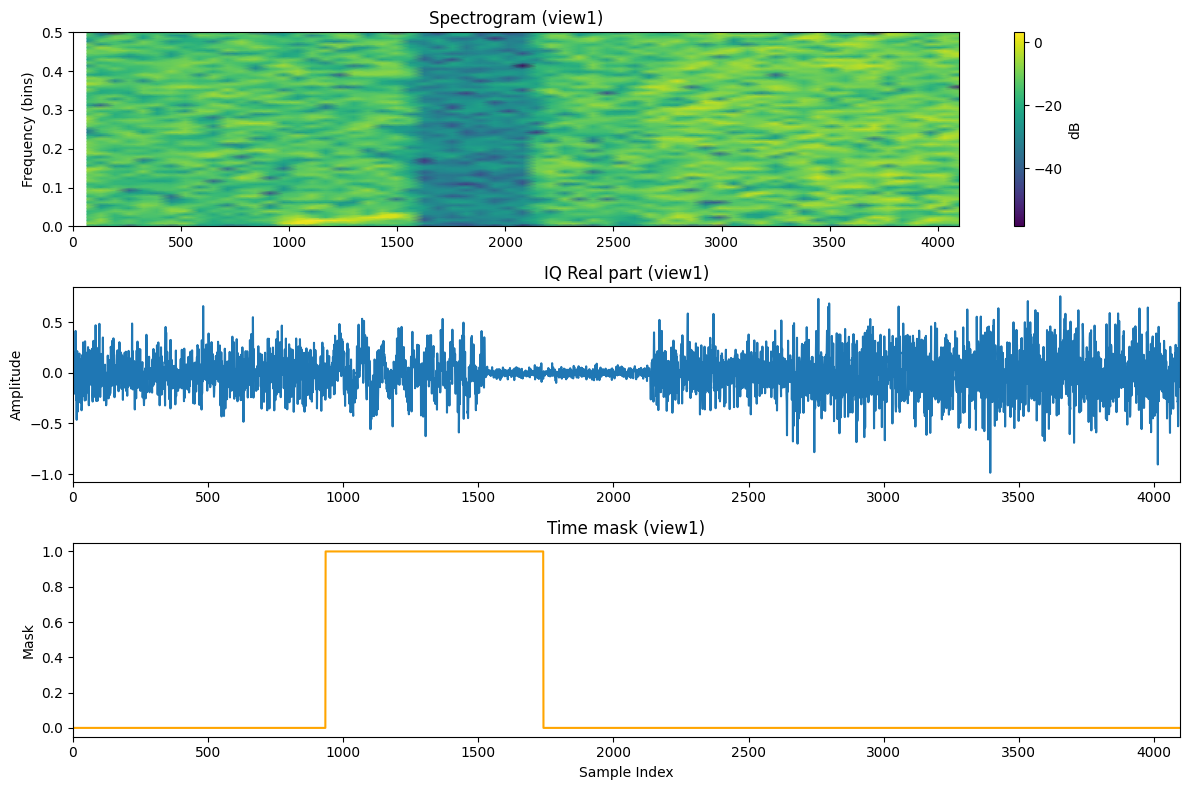

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ✅ Select sample index to visualize
sample_idx = 0

# ✅ Extract IQ and mask
iq = view1_iq[sample_idx].numpy()  # shape [2, L]  → e.g. [2, 4096]
mask = view1_mask[sample_idx].numpy()  # shape [L] → e.g. [4096]

# ✅ Setup spectrogram params to match IQ length
nperseg = 128
noverlap = 64
fs = 1  # Sampling frequency is arbitrary unit

# ✅ Compute spectrogram
f, t_spec, Sxx = spectrogram(iq[0], fs=fs, nperseg=nperseg, noverlap=noverlap)

# ✅ Convert spectrogram time axis into full sample index (same domain as mask & IQ)
t_spec_samples = t_spec * (len(iq[0]) / t_spec[-1])  # Rescale time axis to match sample indices

plt.figure(figsize=(12, 8))

# ✅ Plot spectrogram
plt.subplot(3, 1, 1)
plt.title("Spectrogram (view1)")
plt.pcolormesh(t_spec_samples, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel("Frequency (bins)")
plt.colorbar(label='dB')
plt.xlim([0, len(iq[0])])

# ✅ Plot IQ real part
plt.subplot(3, 1, 2)
plt.title("IQ Real part (view1)")
plt.plot(np.arange(len(iq[0])), iq[0])
plt.ylabel("Amplitude")
plt.xlim([0, len(iq[0])])

# ✅ Plot mask
plt.subplot(3, 1, 3)
plt.title("Time mask (view1)")
plt.plot(np.arange(len(mask)), mask, color='orange')
plt.xlabel("Sample Index")
plt.ylabel("Mask")
plt.xlim([0, len(iq[0])])

plt.tight_layout()
plt.show()



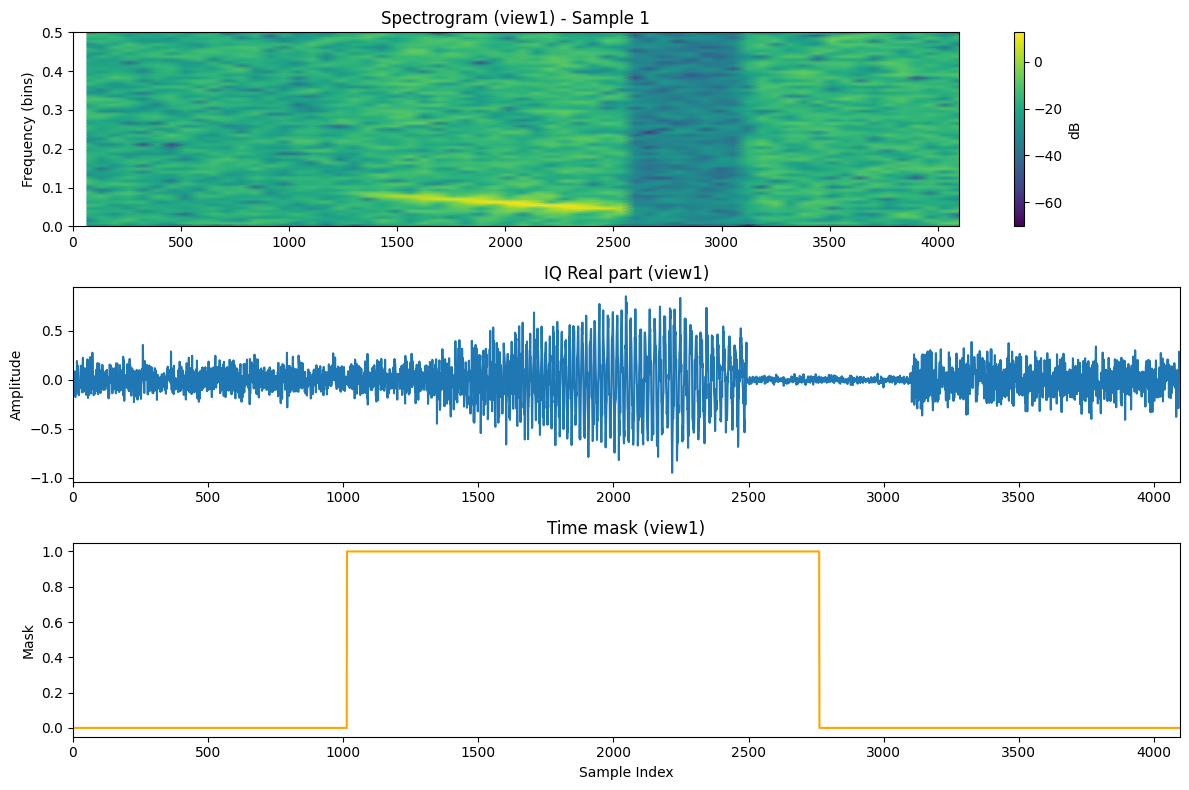

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Create iterator outside the cell (only once)
if "sample_iterator" not in globals():
    loader = datamodule.train_dataloader()
    batch = next(iter(loader))
    ((view1_iq, view1_mask), (view2_iq, view2_mask)), labels = batch
    sample_iterator = iter(range(view1_iq.shape[0]))

# Get next sample
try:
    sample_idx = next(sample_iterator)
except StopIteration:
    print("✅ All samples visualized in current batch.")
    del sample_iterator
    raise

# Visualization code
iq = view1_iq[sample_idx].numpy()
mask = view1_mask[sample_idx].numpy()

f, t_spec, Sxx = spectrogram(iq[0], nperseg=128, noverlap=64)
t_spec_samples = t_spec * (len(iq[0]) / t_spec[-1])

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.title(f"Spectrogram (view1) - Sample {sample_idx}")
plt.pcolormesh(t_spec_samples, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel("Frequency (bins)")
plt.colorbar(label='dB')
plt.xlim([0, len(iq[0])])

plt.subplot(3, 1, 2)
plt.title("IQ Real part (view1)")
plt.plot(np.arange(len(iq[0])), iq[0])
plt.ylabel("Amplitude")
plt.xlim([0, len(iq[0])])

plt.subplot(3, 1, 3)
plt.title("Time mask (view1)")
plt.plot(np.arange(len(mask)), mask, color='orange')
plt.xlabel("Sample Index")
plt.ylabel("Mask")
plt.xlim([0, len(iq[0])])

plt.tight_layout()
plt.show()
